### Imports


In [1]:
%load_ext autoreload
%autoreload 2

In [32]:
import torch as t
from basin_volume import *
from tqdm.notebook import tqdm
from jaxtyping import Float
from torch import Tensor
from typing import Optional
import copy
from typing import List

### Loading model & data

In [3]:
device = t.device("cuda:7" if t.cuda.is_available() else "cpu")
t.set_default_device(device)

In [4]:
RUNS_DIR = "/mnt/ssd-1/adam/basin-volume/runs"

In [5]:
# model checkpoints are at 2^i, i\in [1,17]
from tyche.convnext import load_convnext_checkpoint


models_clean = [
    load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p001/checkpoint-{2**(step+1)}").to(
        device
    )
    for step in range(1)
]
# models_poisoned = [
#     load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p4/checkpoint-{2**(step+1)}").to(
#         device
#     )
#     for step in range(16)
# ]

In [6]:
from tyche.convnext import load_cifar10_splits_dict


cifar10_ds = load_cifar10_splits_dict(size=1024)

In [7]:
val_ds = cifar10_ds["val"].to(device)
clean_ds = cifar10_ds["clean"].to(device)
poisoned_ds = cifar10_ds["poison"].to(device)
val_ds_labels = cifar10_ds["val_labels"].to(device)
clean_ds_labels = cifar10_ds["clean_labels"].to(device)
poisoned_ds_labels = cifar10_ds["poison_labels"].to(device)

In [8]:
val_ds_labels.shape

torch.Size([1024])

In [9]:
def logit_loss(p: Float[t.Tensor, "batch_size d_output"], q: Float[t.Tensor, ""]):
    log_p = p - t.logsumexp(p, dim=-1, keepdim=True)  # log softmax of p
    log_q = q - t.logsumexp(q, dim=-1, keepdim=True)  # log softmax of q

    # KL = sum(exp(log_p) * (log_p - log_q))
    return (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean()

### SGLD sampling

In [10]:
from dataclasses import dataclass


@dataclass
class SGLDParams:
    """See https://arxiv.org/pdf/2308.12108#page=20 for details."""

    eps: float = 1  # total step size of SGLD step
    gamma: float = (
        1  # radius of the ball, controls how far we stray away from w* (higher is more exploration)
    )
    beta: float = 1  # temperature, scales the SGD part (as opposed to the noise part)
    num_steps: int = 1
    batch_size: int = 128  # batch size

In [11]:
def sgld(
    model,
    sgld_params: SGLDParams,
    dataset: Optional[Float[Tensor, "batch_size ..."]],
    cost_fn: List[str] = ["cross_entropy"],
):
    """Run SGLD on the model using the given dataset and cost function."""

    sgld_dict = {}
    sgld_dict["params"] = sgld_params
    sgld_dict["loss"] = []

    array_loss = []

    optimizer = t.optim.SGD(model.parameters(), lr=1)
    model = copy.deepcopy(model)

    w_0 = (
        t.nn.utils.parameters_to_vector(model.parameters()).detach().clone().to(device)
    )
    with t.no_grad():
        logits_init = model(dataset[0])["logits"]

    for step in tqdm(range(sgld_params.num_steps)):

        optimizer.zero_grad()

        w = t.nn.utils.parameters_to_vector(model.parameters())

        eta = t.randn_like(w, device=device) * t.sqrt(t.tensor(sgld_params.eps))

        indices = t.randint(0, dataset[0].shape[0], (sgld_params.batch_size,))

        input, labels = dataset[0][indices], dataset[1][indices]

        logits = model(input)["logits"]

        if cost_fn == "KL":
            cost = logit_loss(logits_init, logits)
        elif cost_fn == "cross_entropy":
            cost = t.nn.functional.cross_entropy(logits, labels)
        grad = t.autograd.grad(cost, w)[0]

    return grad

In [12]:
# Set deterministic behavior
t.manual_seed(42)
t.cuda.manual_seed(42)
t.backends.cudnn.deterministic = True
t.backends.cudnn.benchmark = False
t.use_deterministic_algorithms(True)

In [13]:
import os


os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [14]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# Only after setting the environment variable, import torch
import torch as t
import copy

# Verify the environment variable is set
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# Then set all other deterministic settings
t.manual_seed(42)
t.cuda.manual_seed(42)
t.cuda.manual_seed_all(42)  # if you are using multi-GPU
t.backends.cudnn.deterministic = True
t.backends.cudnn.benchmark = False

# Try setting deterministic algorithms and verify it worked
try:
    t.use_deterministic_algorithms(True)
    print("Successfully enabled deterministic algorithms")
except Exception as e:
    print("Error enabling deterministic algorithms:", e)

# You can also check if deterministic algorithms are enabled
print("Deterministic algorithms enabled:", t.are_deterministic_algorithms_enabled())

CUBLAS_WORKSPACE_CONFIG: :4096:8
Successfully enabled deterministic algorithms
Deterministic algorithms enabled: True


In [15]:
print(t.__version__)
print(t.version.cuda)

2.6.0+cu124
12.4


In [157]:
dataset = [val_ds, val_ds_labels]
model = models_clean[0]
model_copy = copy.deepcopy(model)


w_0 = (
    t.nn.utils.parameters_to_vector(model_copy.parameters()).detach().clone().to(device)
)
with t.no_grad():
    logits_init = model_copy(dataset[0])["logits"]

sgld_params = SGLDParams(eps=1e-4, gamma=0, beta=1, batch_size=1, num_steps=20)
optimizer = t.optim.SGD(model_copy.parameters(), lr=1e-4)

cost_fn = "cross_entropy"
indices = t.randint(0, dataset[0].shape[0], (sgld_params.batch_size,))

loss = []
for step in tqdm(range(sgld_params.num_steps)):

    optimizer.zero_grad()

    input, labels = dataset[0][indices], dataset[1][indices]

    logits = model_copy(input)["logits"]

    if cost_fn == "KL":
        cost = logit_loss(logits_init, logits)
    elif cost_fn == "cross_entropy":
        cost = t.nn.functional.cross_entropy(logits, labels)

    loss.append(cost.item())
    # L2 norm of w_0 - w
    w = t.nn.utils.parameters_to_vector(model_copy.parameters())

    l2_norm = t.norm(w - w_0) ** 2
    sgld_loss = (
        sgld_params.eps
        / 2
        * (
            sgld_params.beta * sgld_params.batch_size * cost
            + 0.5 * sgld_params.gamma * l2_norm
        )
    )
    sgld_loss = cost
    sgld_loss.backward()
    optimizer.step()

    # add Gaussian noise to the model parameters
    eta = t.randn_like(w, device=device) * t.sqrt(t.tensor(sgld_params.eps))
    eta = 0 * eta
    new_params = t.nn.utils.parameters_to_vector(model_copy.parameters())
    t.nn.utils.vector_to_parameters(new_params, model_copy.parameters())

  0%|          | 0/20 [00:00<?, ?it/s]

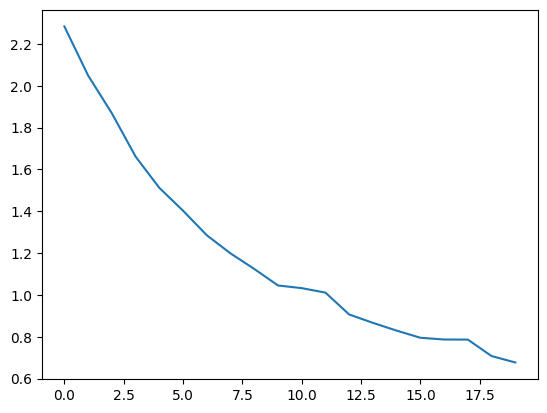

In [158]:
# plot test
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(loss)), loss)

In [159]:
# Define the number of epochs

model = copy.deepcopy(models_clean[0])
# Define the loss function
criterion = t.nn.CrossEntropyLoss()

# Define the optimizer
optimizer = t.optim.SGD(model.parameters(), lr=1e-4, momentum=0)
loss_list = []
# Training loop
for epoch in tqdm(range(20)):
    model.train()
    running_loss = 0.0

    # Get all inputs and labels
    inp, lab = input, labels

    # Zero the parameter gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inp)["logits"]
    loss = criterion(outputs, lab)
    loss_list.append(loss.item())
    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    # Print statistics
    running_loss += loss.item()

print("Finished Training")

  0%|          | 0/20 [00:00<?, ?it/s]

Finished Training


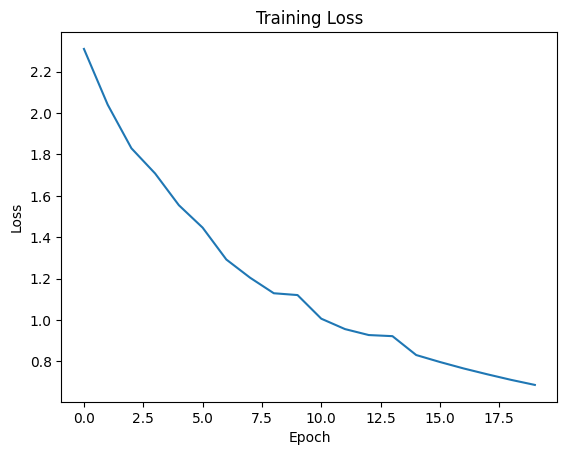

In [160]:
# Plot the loss
plt.plot(np.arange(len(loss_list)), loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()